In [ ]:
import numpy as np
from pathlib import Path
from torch.utils.data import random_split
from model.S_learner import SLearnerEstimator
from data.dataset import load_ihdp_data, IPDHDataset, IPHDDataLoader
from utils.metric import pehe, policy_risk, uplift_curve, uplift_auc_score, qini_curve_industry, qini_auc_score_industry
from utils.plot import plot_uplift_curve, plot_qini_curve

In [2]:
train_path = Path('data/ihdp_npci_1-100.train.npz')
data_dict = load_ihdp_data(train_path)
full_dataset = IPDHDataset(data_dict)
train_ratio = 0.8
train_size = int(train_ratio * len(full_dataset))
valid_size = len(full_dataset) - train_size
train_set, valid_set = random_split(full_dataset, [train_size, valid_size])
train_loader = IPHDDataLoader(train_set, batch_size=32, shuffle=True)
valid_loader = IPHDDataLoader(valid_set, batch_size=32, shuffle=False)

test_path = Path('data/ihdp_npci_1-100.test.npz')
test_data = load_ihdp_data(test_path)
test_set = IPDHDataset(test_data)
test_loader = IPHDDataLoader(test_set, batch_size=32, shuffle=False)

In [3]:
slearner = SLearnerEstimator(x_dim = 25, hidden_dim = 64, lr=1e-3)
slearner.fit(train_loader, valid_loader, 100)
tau_hat_list, tau_true_list = slearner.evaluate(test_loader)

Ep  1 | train=13.4317 | val=10.3584
Ep  2 | train=8.4689 | val=4.1685
Ep  3 | train=4.4681 | val=3.4249
Ep  4 | train=3.4039 | val=3.0577
Ep  5 | train=2.8999 | val=2.7264
Ep  6 | train=2.5504 | val=2.5079
Ep  7 | train=2.2472 | val=2.2197
Ep  8 | train=1.9645 | val=1.9330
Ep  9 | train=1.6887 | val=1.6611
Ep 10 | train=1.4798 | val=1.4428
Ep 11 | train=1.2805 | val=1.2541
Ep 12 | train=1.1863 | val=1.1646
Ep 13 | train=1.1053 | val=1.1180
Ep 14 | train=1.0728 | val=1.1510
Ep 15 | train=1.0239 | val=1.0826
Ep 16 | train=0.9792 | val=1.1384
Ep 17 | train=0.9652 | val=1.0583
Ep 18 | train=0.9358 | val=1.0502
Ep 19 | train=0.9138 | val=1.0716
Ep 20 | train=0.8925 | val=1.0481
Ep 21 | train=0.8637 | val=1.0567
Ep 22 | train=0.9078 | val=1.0439
Ep 23 | train=0.8423 | val=1.0500
Ep 24 | train=0.8588 | val=1.0361
Ep 25 | train=0.8378 | val=1.1023
Ep 26 | train=0.7991 | val=1.0708
Ep 27 | train=0.7865 | val=1.1242
Ep 28 | train=0.7789 | val=1.1128
Ep 29 | train=0.7347 | val=1.0551
✅ 早停触发！停止训练


In [4]:
pehe_score = pehe(tau_hat_list, tau_true_list)
print("PEHE:", pehe_score)

PEHE: 0.6384922


In [5]:
uplift_auc_score(tau_hat_list, test_data['t'], test_data['y'])

10.448265965779626

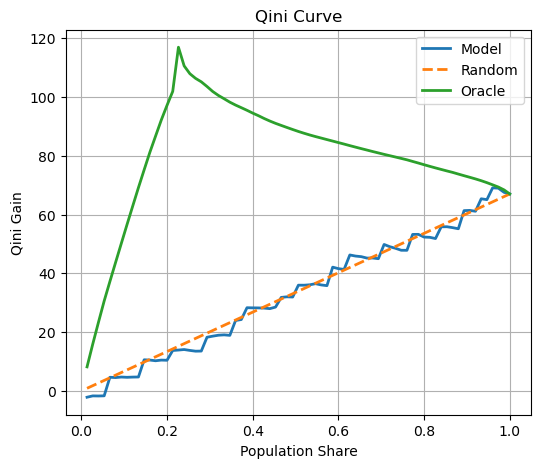

In [6]:
plot_qini_curve(tau_hat_list, test_data['t'], test_data['y'])

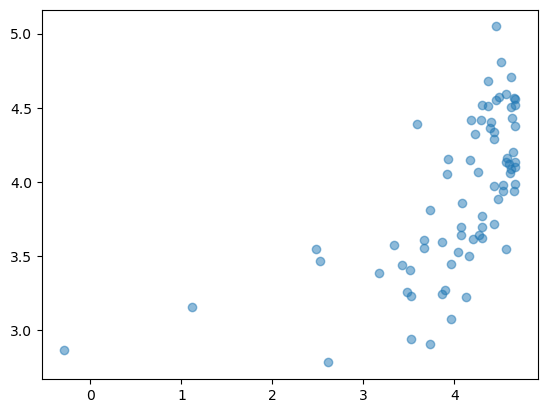

In [7]:
import matplotlib.pyplot as plt
plt.scatter(tau_true_list, tau_hat_list, alpha=0.5)

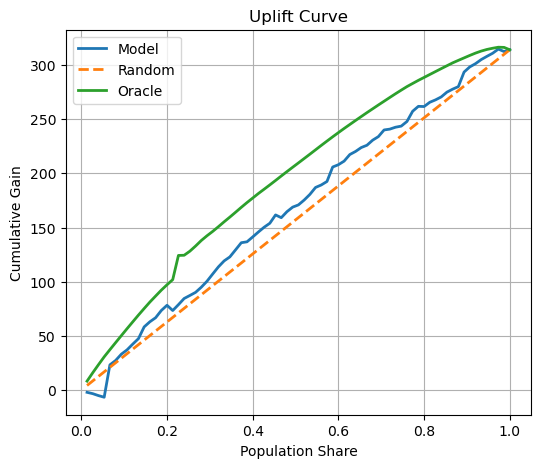

In [8]:
plot_uplift_curve(tau_hat_list, test_data['t'], test_data['y'])